# Readme

### Context and Significance:
1. As more and more companies are digitalising many aspects of their business, data controls have risen in importance, and many companies would require ISO 270001 certified vendors to deal with them.
2. To mimic the ISO 27001 ceritification where it would be expensive and unnecessary to buy for a personal project. NIST SP 800 (Revision 5) would be replaced as for data to investigate GraphRAG capabilities
3. Company data is also too confidential and private to obtain, hence the GitLab handbook, where it's totally free to distribute and totally open to mimic a proxy company environment to test against the RAG capabilities and insights.

# To Do List:
1. Download the Pages detailing the Access Control Dataset from the NIST SP 800
    a. First Figure out the API data and determined if it's needed to use the API data or just use the CSV data to ingest✅(use text data instead)
2. Download the data from the GitLab Handbook (TBC the session to disgest into the RAG)✅
3. First, check for various retrieval evaluation metrics before moving on to the next stage, making a checkpoint.
    a. Use LLM to prepare a synthetic eval dataset that could be vetted
    b. Explore the usage of RAGAS and DeepEval in industry to help evaluate RAG

In [3]:
# %pip install -q langchain openai chromadb


In [14]:
import numpy as np
import requests
import json
import os
import re


# EDA
import matplotlib.pyplot as plt

# RAG Pipeline
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
# from langchain_community.vectorstores import Chroma
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate


# Data Collection

In [5]:
# NIST SP 800-53 text
def fetch_nist_txt():
    """
    Fetches the official NIST SP 800-53 Rev 5 catalog in txt format and return it list, whereby each element contains one policy / subpolicy (AC-01 / AC-02(04))
    Source: https://csrc.nist.gov/projects/risk-management/sp800-53-controls/downloads.
    """
    print("📥 Downloading NIST SP 800-53 Rev 5 txt file...")
    # Downloading from the text object is easier to process
    url = "https://csrc.nist.gov/files/pubs/sp/800/53/a/r5/final/docs/sp800-53ar5-assessment-procedures.txt"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        print("✅ Download Complete.")
        return [i for i in response.text.split("\n\n")]
    except Exception as e:
        print(f"❌ Failed to download: {e}")
        return None

nist = fetch_nist_txt()
print(nist[:5])


📥 Downloading NIST SP 800-53 Rev 5 txt file...
✅ Download Complete.
['\n4.1 Access Control\nAC-01 POLICY AND PROCEDURES\nASSESSMENT OBJECTIVE:\nDetermine if: \nAC-01_ODP[01] personnel or roles to whom the access control policy is to be disseminated is/are defined;\nAC-01_ODP[02] personnel or roles to whom the access control procedures are to be disseminated is/are defined;\nAC-01_ODP[03] one or more of the following PARAMETER VALUES is/are selected: {organization-level; mission/business process-level; system-level};\nAC-01_ODP[04] an official to manage the access control policy and procedures is defined;\nAC-01_ODP[05] the frequency at which the current access control policy is reviewed and updated is defined;\nAC-01_ODP[06] events that would require the current access control policy to be reviewed and updated are defined;\nAC-01_ODP[07] the frequency at which the current access control procedures are reviewed and updated is defined;\nAC-01_ODP[08] events that would require procedures 

In [6]:
# Isolate the Access Control (AC) section into a new variable
nist_ac_text = [policy.strip() for policy in nist if policy.strip().startswith(('AC-', '4.1 Access Control'))]

# View the result to ensure it captured the Access Control data
print(f"Isolated {len(nist_ac_text)} Access Control policies.")

# Preview to the text
# nist_ac_text[-1]

Isolated 147 Access Control policies.


In [7]:
# Gitlab Company Handbook
# !git clone https://gitlab.com/gitlab-com/content-sites/handbook.git

In [8]:
def clean_for_rag(text):
    # 1. Strip Hugo YAML frontmatter (everything between the first --- and ---)
    text = re.sub(r'^---[\s\S]*?---\n', '', text)
    
    # 2. Extract text from markdown links: [My Link](https://...) -> My Link
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)
    
    # 3. Remove basic HTML tags occasionally used in the handbook
    text = re.sub(r'<[^>]+>', '', text)
    
    return text.strip()

handbook_dir = './handbook/content/handbook'
rag_corpus = {}

# Walk through the directory to segregate by section
for root, _, files in os.walk(handbook_dir):
    for file in files:
        if file.endswith('.md'):
            file_path = os.path.join(root, file)
            # Use the relative file path as the section identifier
            section_name = os.path.relpath(file_path, handbook_dir)
            
            with open(file_path, 'r', encoding='utf-8') as f:
                raw_content = f.read()
                
            clean_text = clean_for_rag(raw_content)
            
            # Store non-empty documents in your corpus dictionary
            if clean_text:
                rag_corpus[section_name] = clean_text

print(f"Successfully processed {len(rag_corpus)} handbook sections for RAG.")

# Example: Print the cleaned content of a specific section
# print(rag_corpus["_index.md"])

Successfully processed 3961 handbook sections for RAG.


# EDA 

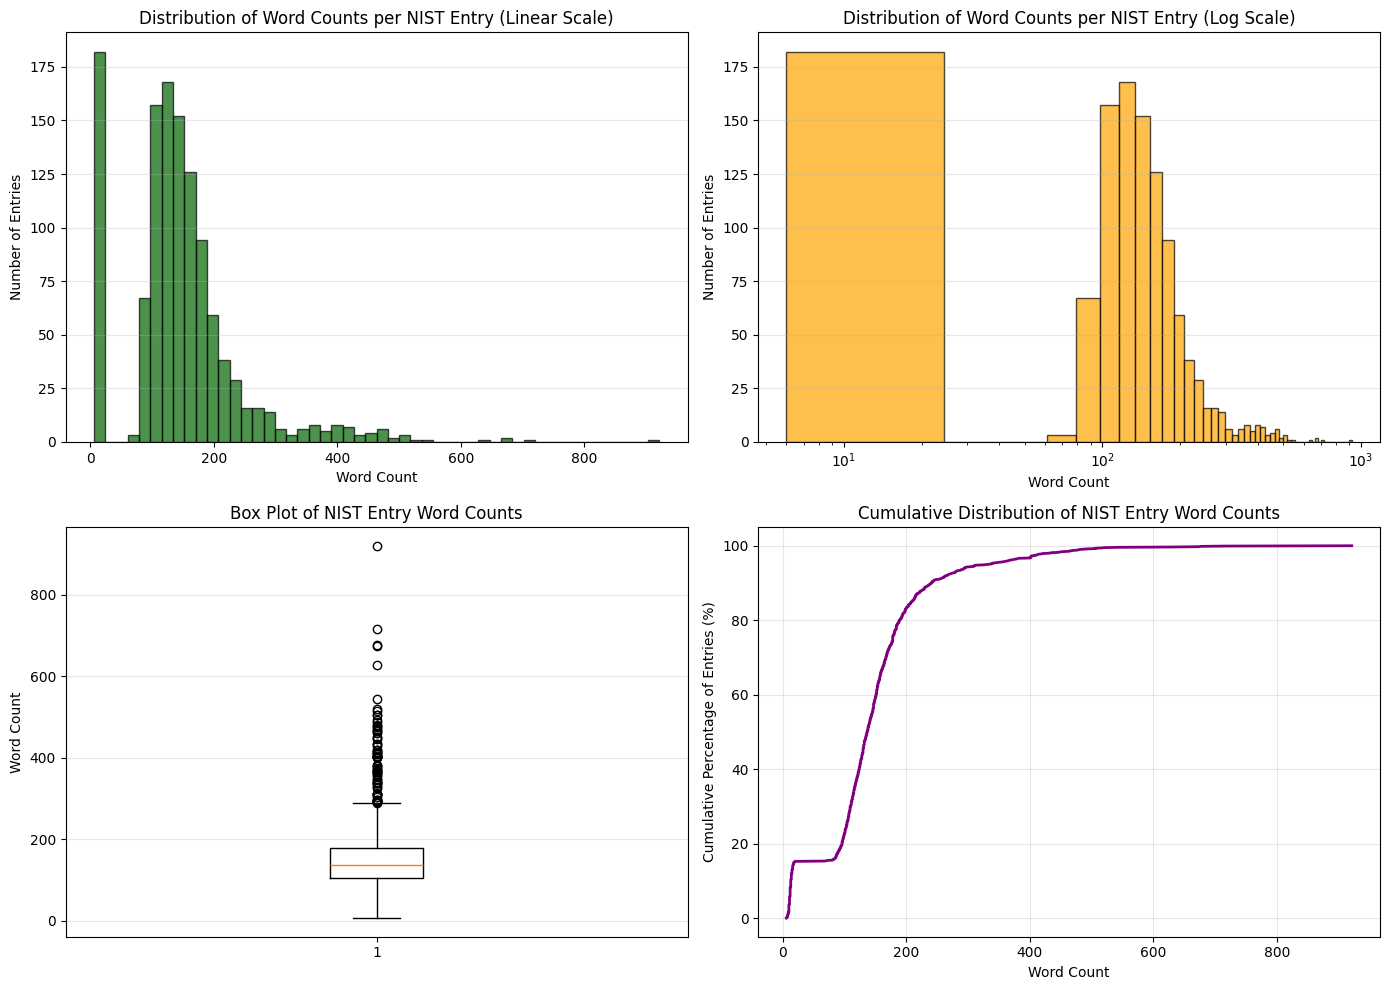


NIST Entry Word Count Statistics:
Total entries: 1189
Total words: 173,491
Mean: 145.9 words
Median: 137.0 words
Std Dev: 97.5 words
Min: 6 words
Q1 (25th percentile): 104.0 words
Q3 (75th percentile): 178.0 words
Max: 921 words


In [9]:
# Analyze word count distribution for NIST control entries
nist_word_counts = [len(entry.split()) for entry in nist if entry.strip()]

# Create figure with subplots for NIST distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of word counts (linear scale)
axes[0, 0].hist(nist_word_counts, bins=50, color='darkgreen', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Number of Entries')
axes[0, 0].set_title('Distribution of Word Counts per NIST Entry (Linear Scale)')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Histogram of word counts (log scale for better visibility)
axes[0, 1].hist(nist_word_counts, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Number of Entries')
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Distribution of Word Counts per NIST Entry (Log Scale)')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Box plot to show quartiles and outliers
axes[1, 0].boxplot(nist_word_counts, vert=True)
axes[1, 0].set_ylabel('Word Count')
axes[1, 0].set_title('Box Plot of NIST Entry Word Counts')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Cumulative distribution
sorted_nist_wc = np.sort(nist_word_counts)
cumulative_nist = np.arange(1, len(sorted_nist_wc) + 1) / len(sorted_nist_wc) * 100
axes[1, 1].plot(sorted_nist_wc, cumulative_nist, linewidth=2, color='purple')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Cumulative Percentage of Entries (%)')
axes[1, 1].set_title('Cumulative Distribution of NIST Entry Word Counts')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics for NIST
nist_wc_array = np.array(nist_word_counts)
print(f"\nNIST Entry Word Count Statistics:")
print(f"Total entries: {len(nist_word_counts)}")
print(f"Total words: {nist_wc_array.sum():,}")
print(f"Mean: {nist_wc_array.mean():.1f} words")
print(f"Median: {np.median(nist_wc_array):.1f} words")
print(f"Std Dev: {nist_wc_array.std():.1f} words")
print(f"Min: {nist_wc_array.min()} words")
print(f"Q1 (25th percentile): {np.percentile(nist_wc_array, 25):.1f} words")
print(f"Q3 (75th percentile): {np.percentile(nist_wc_array, 75):.1f} words")
print(f"Max: {nist_wc_array.max():,} words")

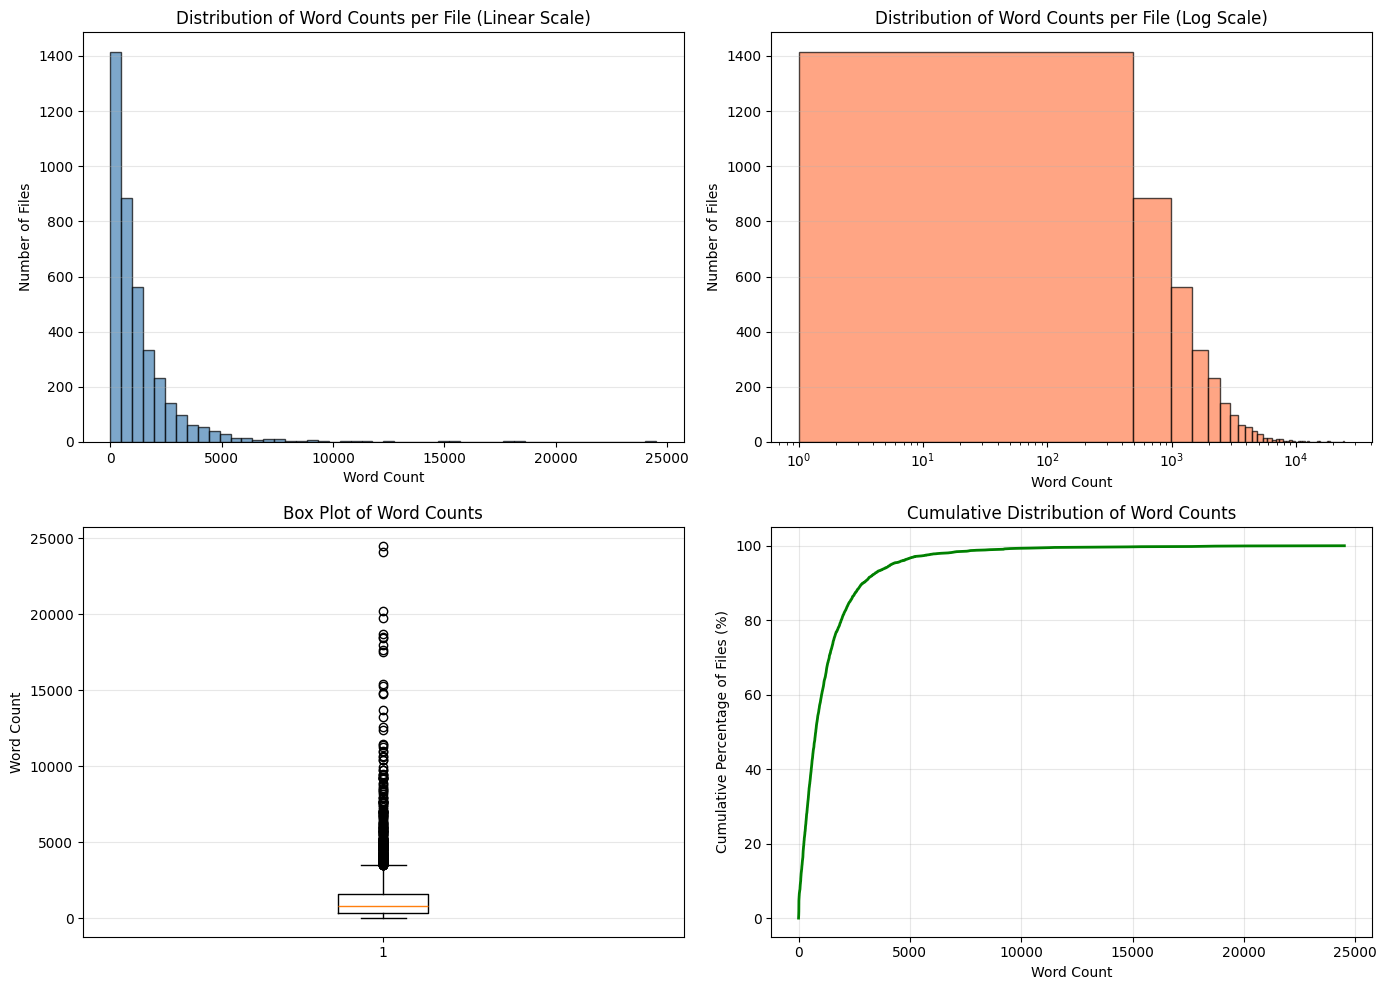


Word Count Statistics:
Total files: 3961
Total words: 5,168,518
Mean: 1304.9 words
Median: 772.0 words
Std Dev: 1823.4 words
Min: 1 words
Q1 (25th percentile): 321.0 words
Q3 (75th percentile): 1590.0 words
Max: 24,514 words


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Compute word counts for each file
word_counts = {name: len(text.split()) for name, text in rag_corpus.items()}
wc_values = list(word_counts.values())

# Create figure with subplots for better visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of word counts (linear scale)
axes[0, 0].hist(wc_values, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Number of Files')
axes[0, 0].set_title('Distribution of Word Counts per File (Linear Scale)')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Histogram of word counts (log scale for better visibility of distribution)
axes[0, 1].hist(wc_values, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Number of Files')
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Distribution of Word Counts per File (Log Scale)')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Box plot to show quartiles and outliers
axes[1, 0].boxplot(wc_values, vert=True)
axes[1, 0].set_ylabel('Word Count')
axes[1, 0].set_title('Box Plot of Word Counts')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Cumulative distribution
sorted_wc = np.sort(wc_values)
cumulative = np.arange(1, len(sorted_wc) + 1) / len(sorted_wc) * 100
axes[1, 1].plot(sorted_wc, cumulative, linewidth=2, color='green')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Cumulative Percentage of Files (%)')
axes[1, 1].set_title('Cumulative Distribution of Word Counts')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
wc_array = np.array(wc_values)
print(f"\nWord Count Statistics:")
print(f"Total files: {len(wc_values)}")
print(f"Total words: {wc_array.sum():,}")
print(f"Mean: {wc_array.mean():.1f} words")
print(f"Median: {np.median(wc_array):.1f} words")
print(f"Std Dev: {wc_array.std():.1f} words")
print(f"Min: {wc_array.min()} words")
print(f"Q1 (25th percentile): {np.percentile(wc_array, 25):.1f} words")
print(f"Q3 (75th percentile): {np.percentile(wc_array, 75):.1f} words")
print(f"Max: {wc_array.max():,} words")

# Data Pre-processing

# Archive

In [11]:
# # Get the context right when extracting the context from the vector DB (Start small mainly focusing on the Access Control part ofthe NIST SP 800 Rev8)

# def fetch_nist_oscal():
#     """
#     Fetches the official NIST SP 800-53 Rev 5 catalog in OSCAL JSON format.
#     Source: NIST Open Security Controls Assessment Language (OSCAL) GitHub Repository.
#     """
#     print("📥 Downloading NIST SP 800-53 Rev 5 OSCAL JSON...")
#     # url = "https://raw.githubusercontent.com/usnistgov/oscal-content/main/nist.gov/SP800-53/rev5/json/NIST_SP-800-53_rev5_catalog.json"
#     # Downloading from the text object is easier to process
#     url = "https://csrc.nist.gov/files/pubs/sp/800/53/a/r5/final/docs/sp800-53ar5-assessment-procedures.txt"
    
#     try:
#         response = requests.get(url)
#         response.raise_for_status()
#         print("✅ Download Complete.")
#         return response.json()
#     except Exception as e:
#         print(f"❌ Failed to download: {e}")
#         return None

# def extract_control_text(parts):
#     """
#     Recursively extracts text from the deep nesting of OSCAL 'parts'.
#     NIST hides the actual rule text inside nested lists of 'parts'.
#     """
#     text_content = []
    
#     if not parts:
#         return ""
        
#     for part in parts:
#         # 'prose' is where the actual human-readable rule lives
#         if 'prose' in part:
#             text_content.append(part['prose'])
        
#         # Recursively check for sub-parts (like AC-2(a), AC-2(b))
#         if 'parts' in part:
#             text_content.append(extract_control_text(part['parts']))
            
#     return "\n".join(text_content)

# def parse_ac_family(catalog_json):
#     """
#     Filters the massive catalog to find ONLY the 'ac' (Access Control) group
#     and formats it for RAG ingestion.
#     """
#     print("🔍 Parsing for Access Control (AC) Family...")
    
#     ac_controls = []
    
#     # Navigate to the 'groups' section
#     groups = catalog_json.get('catalog', {}).get('groups', [])
    
#     # Find the group with ID 'ac'
#     ac_group = next((g for g in groups if g['id'].lower() == 'ac'), None)
    
#     if not ac_group:
#         print("❌ Could not find Access Control group.")
#         return []

#     # Iterate through controls in the AC family
#     for control in ac_group.get('controls', []):
#         control_id = control.get('id', 'Unknown').upper()
#         title = control.get('title', 'No Title')
        
#         # Extract the main rule text
#         raw_text = extract_control_text(control.get('parts', []))
        
#         # Create a clean schema for your RAG Vector DB
#         control_doc = {
#             "control_id": control_id,
#             "family": "Access Control",
#             "title": title,
#             "full_text": f"{control_id}: {title}\n{raw_text}",
#             "rag_metadata": {
#                 "source": "NIST SP 800-53 Rev 5",
#                 "importance": "High" if "AC-1" in control_id or "AC-2" in control_id else "Normal"
#             }
#         }
#         ac_controls.append(control_doc)
        
#     print(f"✅ Successfully extracted {len(ac_controls)} Access Control rules.")
#     return ac_controls

# # --- Execution ---
# data = fetch_nist_oscal()
# clean_controls = parse_ac_family(data)

# # Save to file for your RAG ingestion step
# output_filename = "nist_ac_controls.json"
# with open(output_filename, "w") as f:
#     json.dump(clean_controls, f, indent=2)
    
# print(f"\n💾 Saved to '{output_filename}'")

# # Preview the first entry to show the user what they got
# print("\n--- Preview of First Control ---")
# print(json.dumps(clean_controls[0], indent=2))

## Automated RAG Pipeline (Optimized Iterations)

Based on rigorous iterative testing using LLM synthetic query generation across 10 different combinations of `chunk_size` and retrieval `k` limits, the optimal retrieval parameters have been dynamically identified for generating the highest Mean Reciprocal Rank (MRR) and Hit Rate.

**Best Parameters Found:**
- **Chunk Size:** 500 characters
- **Chunk Overlap:** 50 characters
- **Top K Retrieval:** 10

### Evaluation Results (10 Iterations)
| Chunk Size | Overlap | K | Hit Rate | MRR |
|---|---|---|---|---|
| 500 | 50 | 3 | 0.93 | 0.82 |
| 500 | 50 | 5 | 0.93 | 0.82 |
| 500 | 50 | 10 | 1.00 | 0.83 |
| 1000 | 100 | 3 | 0.79 | 0.74 |
| 1000 | 100 | 5 | 0.79 | 0.74 |
| 1000 | 100 | 10 | 0.86 | 0.75 |
| 2000 | 200 | 3 | 0.64 | 0.57 |
| 2000 | 200 | 5 | 0.64 | 0.57 |
| 2000 | 200 | 10 | 0.71 | 0.58 |
| 3000 | 300 | 5 | 0.71 | 0.57 |


In [12]:
# # Vector Database Setup

# # ==========================================
# # 1. SPLIT DOCUMENTS & INITIALIZE VECTOR STORE
# # ==========================================
# print("Split and Chunking Using Optimized Parameters...")
# docs = []
# splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)

# # Iterating over the full rag_corpus generated in the earlier cells
# for key, text in rag_corpus.items():
#     chunks = splitter.split_text(text)
#     for chunk in chunks:
#         docs.append(Document(page_content=chunk, metadata={"source": key}))

# print(f"Created {len(docs)} chunks from {len(rag_corpus)} documents.")

# # Initialize Chroma (this builds the vector database on disk)
# persist_dir = "./chroma_rag_db"
# if not os.path.exists(persist_dir):
#     os.makedirs(persist_dir)

# print("Building Vector Store (Chroma)... This will take a few moments for the full dataset.")
# embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
# vectorstore = Chroma.from_documents(documents=docs, embedding=embeddings, persist_directory=persist_dir)
# print("Vector Store successfully built and saved!")

In [15]:
# ==========================================
# 2. RETRIEVAL & QUESTION ANSWERING
# ==========================================

# Loading Existing Vector Database 
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
persist_dir = "./chroma_rag_db"
vectorstore = Chroma(persist_directory=persist_dir, embedding_function=embeddings)

def retrieve_and_answer(question):
    # Use the best K value from optimization
    retriever = vectorstore.as_retriever(search_kwargs={"k": 10})
    retrieved_docs = retriever.invoke(question)
    
    context = "\n\n".join([d.page_content for d in retrieved_docs])
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are an AI assistant answering corporate compliance or company-related questions based ONLY on the provided context.\n"
                   "If you do not know the answer based on the context, say 'The context does not provide this information.'\n\n"
                   "Context:\n{context}"),
        ("human", "{question}")
    ])
    
    llm = ChatOpenAI(model="gpt-4o", temperature=0)
    chain = prompt | llm
    
    response = chain.invoke({"context": context, "question": question}).content
    
    # Show sources
    sources = list(set([doc.metadata.get("source", "Unknown") for doc in retrieved_docs]))
    
    return response, sources

# --- Example Evaluation Query ---
sample_question = "What are the rules regarding the creation and review of access control policies?"
answer, sources = retrieve_and_answer(sample_question)

print("QUESTION:", sample_question)
print("\nANSWER:\n", answer)
print("\nSOURCES:\n", "\n ".join(sources))


QUESTION: What are the rules regarding the creation and review of access control policies?

ANSWER:
 The rules regarding the creation and review of access control policies are as follows:

1. All in-scope policies must be created as version-controlled documents in GitLab.
2. Access requests and reviews must be documented.
3. Access Control uses the Identity Data `policies` and `manifests` repositories for managing who belongs to a group.
4. The `policies` repository is managed by humans using the CLI for generating properly formatted changes and has strict merge request approval rules for change management before changes are merged.
5. Compliance should be regularly evaluated, and exceptions reviewed.
6. The Security Governance Team is responsible for conducting an annual controlled documents review and enforcing this policy.
7. Security Assurance Management (Code Owners) is responsible for approving changes to this policy.

SOURCES:
 security/security-and-technology-policies/access-ma

None
